In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
historical_data = pd.read_csv("datasets/historical_data.csv")
historical_data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [4]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  object 
 2   actual_delivery_time                          197421 non-null  object 
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  object 
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                19

In [5]:
historical_data["created_at"] = pd.to_datetime(historical_data['created_at'])
historical_data["actual_delivery_time"] = pd.to_datetime(historical_data['actual_delivery_time'])

In [6]:
# feature creation
# create the target variable for regression
from datetime import datetime
historical_data["actual_total_delivery_duration"] = (historical_data["actual_delivery_time"] - historical_data["created_at"]).dt.total_seconds()/60.0

In [7]:
historical_data["busy_dashers_ratio"] = historical_data["total_busy_dashers"]/historical_data["total_onshift_dashers"]

In [8]:
# a new feature which might useful
historical_data["estimated_non_prep_duration"] = historical_data["estimated_store_to_consumer_driving_duration"] + historical_data["estimated_order_place_duration"]

In [9]:
# data preparation for modelling

In [10]:
# check ids and decide whether to encode them or not
historical_data["market_id"].nunique()

6

In [11]:
historical_data["store_id"].nunique()

6743

In [12]:
historical_data["order_protocol"].nunique()

7

In [13]:
# create dummies for order protocol
order_protocol_dummies = pd.get_dummies(historical_data.order_protocol)
order_protocol_dummies = order_protocol_dummies.add_prefix('order_protocol_dummies')
order_protocol_dummies = order_protocol_dummies.astype(int) #for True as 1 and False as 0

In [14]:
order_protocol_dummies.head()

,order_protocol_dummies1.0,order_protocol_dummies2.0,order_protocol_dummies3.0,order_protocol_dummies4.0,order_protocol_dummies5.0,order_protocol_dummies6.0,order_protocol_dummies7.0
0,1,0,0,0,0,0,0
1,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0


In [15]:
# create dummy variables for market_id
market_id_dummies = pd.get_dummies(historical_data.market_id)
market_id_dummies = market_id_dummies.add_prefix('market_id_dummies')
market_id_dummies = market_id_dummies.astype(int)

In [16]:
market_id_dummies.head()

,market_id_dummies1.0,market_id_dummies2.0,market_id_dummies3.0,market_id_dummies4.0,market_id_dummies5.0,market_id_dummies6.0
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,1,0,0,0
3,0,0,1,0,0,0
4,0,0,1,0,0,0


In [17]:
# create dictionary with most repeated categories of each store to fill the null rows where it is possible
store_id_unique = historical_data["store_id"].unique().tolist()
store_id_and_category = {
    store_id: 
        historical_data[historical_data.store_id == store_id].store_primary_category.mode().iloc[0] if not historical_data[historical_data.store_id == store_id].store_primary_category.mode().empty else None
        for store_id in store_id_unique
}

In [18]:
def fill(store_id):
    """Return primary store category from the dictionary"""
    try:
        return store_id_and_category[store_id]
    except:
        return np.nan
    
# fill null values
historical_data["nan_free_store_primary_category"] = historical_data.store_id.apply(fill)

In [19]:
# create dummies for store primary category
store_primary_category_dummies = pd.get_dummies(historical_data.nan_free_store_primary_category)
store_primary_category_dummies = store_primary_category_dummies.add_prefix('category_')
store_primary_category_dummies = store_primary_category_dummies.astype(int)

In [20]:
store_primary_category_dummies.head()

,category_afghan,category_african,category_alcohol,category_alcohol-plus-food,category_american,category_argentine,category_asian,category_barbecue,category_belgian,category_brazilian,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# drop created_at, market_id, store_id, store_primary_category, actual_delivery_time, nan_free_store_primary_category

train_df = historical_data.drop(columns=[
    "created_at",
    "market_id",
    "store_id",
    "store_primary_category",
    "actual_delivery_time",
    "nan_free_store_primary_category"
])

train_df.head()

,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,actual_total_delivery_duration,busy_dashers_ratio,estimated_non_prep_duration
0,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0,62.983333,0.424242,1307.0
1,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0,67.066667,2.000000,1136.0
2,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0,29.683333,0.000000,1136.0
3,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0,51.250000,1.000000,735.0
4,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0,39.833333,1.000000,1096.0


In [22]:
train_df = pd.concat([train_df, order_protocol_dummies, market_id_dummies, store_primary_category_dummies], axis=1)

In [23]:
# align dtype over dataset
train_df = train_df.astype("float32")
train_df.head()

,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
0,1.0,4.0,3441.0,4.0,557.0,1239.0,33.0,14.0,21.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,3.0,3900.0,3.0,1100.0,1600.0,6.0,6.0,9.0,446.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
train_df.describe()

c:\Users\sayon\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
count,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000,197428.000000,...,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000
mean,2.882352,3.196391,2682.331543,2.670791,686.218445,1159.588623,44.808094,41.739746,58.050064,308.560181,...,0.000815,0.000187,0.005465,0.011300,0.000740,0.037254,0.001175,0.001433,0.004234,0.030928
std,1.503771,2.666546,1823.093628,1.630255,522.038635,558.411377,34.526783,32.145733,52.661831,90.139656,...,0.028545,0.013689,0.073725,0.105701,0.027184,0.189384,0.034260,0.037834,0.064935,0.173122
min,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000,251.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000,251.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000,446.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2715.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
train_df["busy_dashers_ratio"].describe()

c:\Users\sayon\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


count    1.775900e+05
mean              NaN
std               NaN
min              -inf
25%      8.269231e-01
50%      9.622642e-01
75%      1.000000e+00
max               inf
Name: busy_dashers_ratio, dtype: float64

In [26]:
# check infinity values with using numpy isinfinite() function
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [27]:
train_df["busy_dashers_ratio"].describe()

count    177551.000000
mean          0.949777
std           0.406184
min         -13.000000
25%           0.826667
50%           0.962264
75%           1.000000
max          31.000000
Name: busy_dashers_ratio, dtype: float64

In [28]:
train_df["busy_dashers_ratio"] = train_df["busy_dashers_ratio"].clip(0, 1)

In [29]:
train_df["busy_dashers_ratio"].describe()

count    177551.000000
mean          0.887007
std           0.162926
min           0.000000
25%           0.826667
50%           0.962264
75%           1.000000
max           1.000000
Name: busy_dashers_ratio, dtype: float64

In [30]:
train_df.shape

(197428, 101)

In [31]:
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_df.dropna(inplace=True)

In [32]:
train_df.shape

(176166, 101)

In [33]:
# separate features and target variable

X = train_df.drop("actual_total_delivery_duration", axis=1)
y = train_df["actual_total_delivery_duration"]

In [34]:
X.shape

(176166, 100)

In [35]:
y.shape

(176166,)

In [36]:
# compute correlation matrix
correlation_matrix = X.corr()
correlation_matrix.head()

,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,...,category_southern,category_spanish,category_steak,category_sushi,category_tapas,category_thai,category_turkish,category_vegan,category_vegetarian,category_vietnamese
order_protocol,1.000000,0.003312,-0.053198,-0.028931,-0.041070,-0.087958,0.146852,0.151523,0.136114,-0.687007,...,0.000145,-0.010904,-0.027090,0.049218,-0.015855,-0.001310,-0.000069,-0.031132,0.000389,0.043129
total_items,0.003312,1.000000,0.556859,0.757858,-0.389074,-0.052938,0.033847,0.030656,0.036166,-0.021976,...,-0.003493,0.002164,-0.009625,0.054752,0.000570,0.032118,-0.000768,-0.005134,-0.005291,-0.031197
subtotal,-0.053198,0.556859,1.000000,0.682964,0.036906,0.507917,0.132234,0.126864,0.131133,0.035675,...,0.003861,0.006298,0.046944,0.067271,-0.001724,0.047646,0.001995,-0.002368,-0.004202,-0.043124
num_distinct_items,-0.028931,0.757858,0.682964,1.000000,-0.446640,0.047700,0.069302,0.063860,0.070640,0.005723,...,-0.002642,0.003108,-0.004687,0.072519,-0.000107,0.071874,0.001753,-0.004981,-0.001111,-0.038290
min_item_price,-0.041070,-0.389074,0.036906,-0.446640,1.000000,0.541311,0.040970,0.042540,0.039721,0.050982,...,0.010537,0.002724,0.041778,-0.006888,-0.001723,-0.035880,0.001816,0.004851,-0.005136,-0.012729


In [37]:
# correlation_matrix = X.corr()
# correlation_matrix.head()
# Why we do this

# Some features may contain the same information.

# Example:

# feature A = price
# feature B = price_in_cents

# These are basically identical.

# If two variables are highly correlated:

# correlation > 0.9

# they confuse some models and add unnecessary complexity.

# So we check correlations.

In [38]:
# find high correlated features

# create absolute correlation matrix
corr_matrix = correlation_matrix.abs()

# select upper triangle of correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# find features with correlation greater than o.9
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

print("Highly correlated features:", to_drop)

Highly correlated features: ['total_busy_dashers', 'total_outstanding_orders', 'estimated_non_prep_duration', 'order_protocol_dummies1.0']


In [39]:
# Remove Highly Correlated Columns

# drop correlated features

X = X.drop(columns=to_drop)

print("Remaining features:", X.shape[1])

Remaining features: 96


In [40]:
# Train/Test Split

# split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (140932, 96)
Testing set: (35234, 96)


In [41]:
# Train First Model

# Train Linear Regression Model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

# train the model
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
#  What happens here

# The model tries to learn a formula like:

# delivery_time =
# a * total_items +
# b * busy_dashers_ratio +
# c * estimated_non_prep_duration

# It learns coefficients a, b, c from the data.

In [43]:
# Make predictions on the test set

# predict delivery times

y_pred = lr_model.predict(X_test)

In [56]:
# Evaluate the model

from sklearn.metrics import mean_squared_error, mean_absolute_error

# compute error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression RMSE:", rmse)
print("Linear Regression MAE:", mae)

Linear Regression RMSE: 18.02812371349016
Linear Regression MAE: 12.695955276489258


In [45]:
# What these metrics mean

# MAE

# average prediction error

# Example:

# MAE = 7 minutes

# means predictions are on average 7 minutes off.

# RMSE

# Penalizes large errors more strongly.

# Lower values = better model.

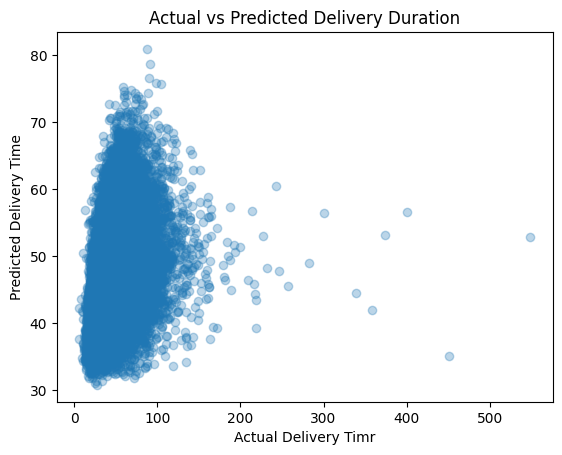

In [46]:
# Visualise Predictions

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Delivery Timr")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Duration")
plt.show()

In [47]:
# Model Evaluation Insight – Actual vs Predicted Delivery Duration

# Observation from the scatter plot:

# The plot compares actual delivery duration (x-axis) with predicted delivery duration (y-axis).

# If the model were perfect, all points would lie along a diagonal line (y = x).

# What we observe instead:

# Most predictions fall between ~30 to 60 minutes, even when actual delivery times vary much more.

# The model struggles to predict very large delivery durations (e.g., 200–500 minutes).

# There are several outliers in the actual delivery time, which the model fails to capture.

# Predictions appear compressed into a narrow band, indicating the model is predicting near the average delivery time.

# Interpretation:

# This behavior suggests underfitting.

# The current model (Linear Regression):

# assumes a linear relationship between features and delivery duration

# cannot capture complex or nonlinear relationships in the data

# Examples of nonlinear factors in real delivery systems:

# traffic fluctuations

# restaurant preparation delays

# driver availability spikes

# order volume surges

# These factors are difficult for a simple linear model to capture.

# Conclusion:

# The Linear Regression model serves as a baseline model, but its predictive performance is limited.

# Next Step:

# To better capture nonlinear relationships in the data, we will train more powerful models such as:

# Random Forest Regressor

# Gradient Boosting models

# These models can learn more complex patterns and are expected to produce more accurate predictions.

In [ ]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# initialize the model
rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=20,       # limit tree depth, trees learn general patterns
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,    #(ensures reproducibility)
    n_jobs=-1           #(this telss sklearn, use all cpu cores. training becomes much faster)
)

In [58]:
# Train the model

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [59]:
# make predictions
rf_predictions = rf_model.predict(X_test)

In [60]:
# evaluate the model

from random import Random

from sklearn.metrics import mean_squared_error, mean_absolute_error

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

Random Forest RMSE: 17.410726575696103
Random Forest MAE: 12.060540060376894


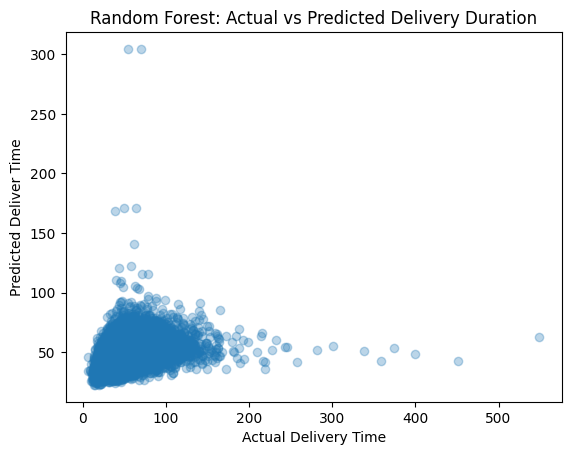

In [61]:
plt.scatter(y_test, rf_predictions, alpha=0.3)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Deliver Time")
plt.title("Random Forest: Actual vs Predicted Delivery Duration")

plt.show()

In [63]:
# Train XGBoost Regressor

from xgboost import XGBRegressor

In [72]:
# initialize the model

xgb_model = XGBRegressor(
    n_estimators = 400,     # number of trees
    learning_rate = 0.05,   # how fast the model learns, slower learning but usually better performance
    max_depth = 6,         # limit tree depth, trees learn general patterns
    subsample = 0.8,    # use 80% of data for each tree, helps prevent overfitting\
    colsample_bytree = 0.8, # use 80% of features for each tree, helps prevent overfitting
    random_state = 42,
    n_jobs = -1
)

In [73]:
# Train the model

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [ ]:
# The model now learns relationships between:

# order size
# restaurant type
# marketplace demand
# driver availability
# estimated durations

In [74]:
# make predictions

xgb_predictions = xgb_model.predict(X_test)

In [75]:
# Evaluate the model

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)

XGBoost RMSE: 17.169979528860377
XGBoost MAE: 11.757647514343262


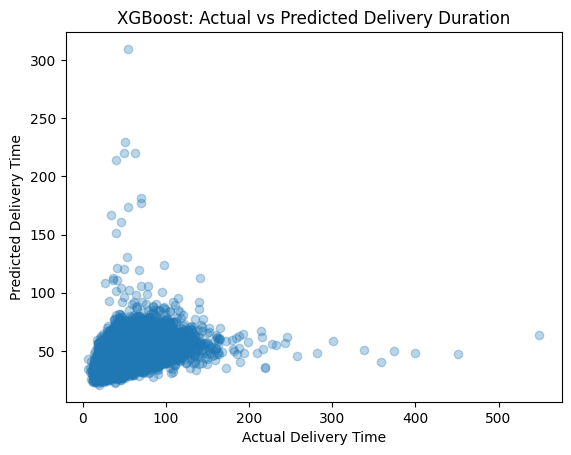

In [76]:
plt.scatter(y_test, xgb_predictions, alpha=0.3)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("XGBoost: Actual vs Predicted Delivery Duration")

plt.show()